In [1]:
import os, sys
sys.path.append(os.path.abspath("..")) 
from src.state_schema import SupervisorState
from src.supervisor_graph import supervisor_node
from src.complaint_graph import complaint_flow
from src.inquiry_graph import inquiry_flow
from src.retention_graph import retention_flow
from src.conversation_graph import greeting_flow, clarification_flow
from rich import print as rprint

/Volumes/LaCie/Projects_portfolio/NLP/Customer Support System/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 106/106 [00:00<00:00, 2016.55it/s, Materializing param=pooler.dense.weight]                                     
DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-small
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver

In [3]:
def build_graph():

    graph = StateGraph(SupervisorState)

    graph.add_node("supervisor",supervisor_node)
    graph.add_node("greeting_flow",greeting_flow)
    graph.add_node("clarification_flow", clarification_flow)
    graph.add_node("complaint_flow", complaint_flow)
    graph.add_node("retention_flow", retention_flow)
    graph.add_node("inquiry_flow", inquiry_flow)

    graph.add_edge(START, "supervisor")
    graph.add_edge("greeting_flow", END)
    graph.add_edge("clarification_flow", END)

    memory = MemorySaver()
    return graph.compile(checkpointer=memory)

graph = build_graph()


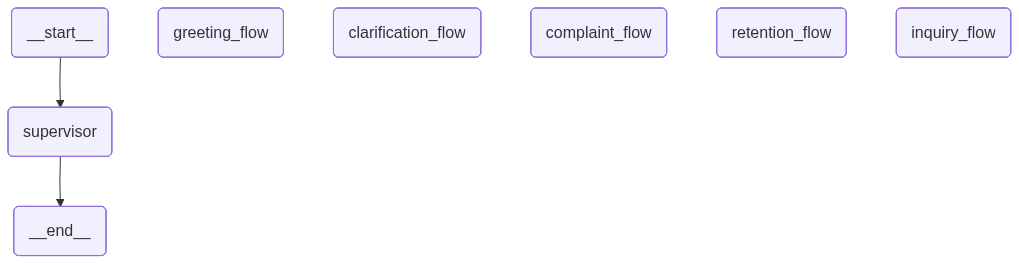

In [4]:
graph

In [5]:
def agent(state:SupervisorState)->SupervisorState:
    config = {"configurable": {"thread_id": "support_session_1"}}
    return graph.invoke(state,config)

In [6]:
test_cases = [
    # --- FLOW 1: GREETINGS & CHITCHAT ---
    {"user_input": "Hello! Is there anyone available to help me with a few questions?"},
    {"user_input": "Good morning, I hope you're having a productive day."},

    # --- FLOW 2: TECHNICAL COMPLAINTS (Complaint Graph) ---
    {"user_input": "My home internet has been dropping every 20 minutes since the rain started."},
    {"user_input": "The screen on my new device is flickering and I can't see the menu."},
    {"user_input": "I've already tried restarting the router, but the red light is still blinking."},

    # --- FLOW 3: ACCOUNT & RETENTION (Retention Graph) ---
    {"user_input": "I want to cancel my subscription effective immediately; it's too expensive."},
    {"user_input": "My contract is up next month and I'm looking at switching to a different provider."},
    {"user_input": "I was promised a discount on my last bill that never showed up. I'm very upset."},

    # --- FLOW 4: GENERAL INQUIRIES (Inquiry Graph) ---
    {"user_input": "How do I set up international roaming for my upcoming trip to Europe?"},
    {"user_input": "What are your store hours for the downtown St. Louis location?"},
    {"user_input": "Can you explain the difference between the Basic and Pro service plans?"},

    # --- FLOW 5: AMBIGUOUS (Clarification Node) ---
    {"user_input": "I'm having a really hard time with this service and I need a solution."},
    {"user_input": "This is the third time I'm reaching out about my order status."},
    {"user_input": "I'm not sure if I'm in the right place, but I need help with my account."},

    # --- MULTI-TURN / STICKY FLOW TESTS (Requires same thread_id) ---
    {"user_input": "My phone won't turn on."}, # Turn 1: Should enter Complaint
    {"user_input": "Yes, I held the power button for 10 seconds like you said."}, # Turn 2: Should stay in Complaint
    {"user_input": "Wait, actually, how much would it cost just to upgrade to a new phone instead?"} # Turn 3: Should pivot or reset
]

In [11]:
res = agent({"user_input":
            #  "Keyboard has issue."})
            "Its iPhone15"})

active_flow --> complaint_flow


In [7]:
res = agent(test_cases[3])

active_flow --> []
active_flow: [], margin: 0.26115162670612335, label: complaint_flow


In [8]:
test_cases[3]

{'user_input': "The screen on my new device is flickering and I can't see the menu."}

In [12]:
for msg in res['messages']:
    rprint(msg.content)

Which product are you having the screen flickering issue with?

Ticket XD482Z18 has been created.

In [13]:
res

{'messages': [HumanMessage(content='Which product are you having the screen flickering issue with?', additional_kwargs={}, response_metadata={}, id='13c2147e-499d-4dbd-a0ec-93829b698498'),
  HumanMessage(content='Ticket XD482Z18 has been created.', additional_kwargs={}, response_metadata={}, id='7ca79a76-4809-4483-abed-70d4a3945c04')],
 'user_input': 'Its iPhone15',
 'observations': [],
 'response': [],
 'complaint_data': {},
 'missing_info': None,
 'active_flow': None}